# 변형: ε_min = 0

![baseline death](figs/eps_crash_short.gif)

## 가설: `eps_min=0.05` → 후반 탐험이 충돌을 유발한다
학습이 끝나도 5% 랜덤행동을 유지 → 뱀이 길어진 후반엔 한 번의 랜덤이 충돌로 이어짐.
→ 따라서 후반엔 ε = 0이어야 스코어가 더 올라갈 것이라 예측.

그래서 `eps_min`만 0.05 → 0으로 바꾼다.

In [1]:
import os
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image 
from snake_game import SnakeGameEnv

device = torch.device("cpu")
print(f"사용 device: {device}")

SEED = 0


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(SEED)

## 환경 설정 & 상태 전처리

- **이진화**: 머리=1, 몸통=2.., 먹이=37 같은 큰 정수가 섞여 있어, 0/1으로 만든다
- **타임아웃**: "먹이 없이 `board²` 스텝이 지나면 종료"를 걸어 무의미한 먹이 찾기를 막는다.

In [2]:
# ── 환경 하이퍼파라미터 ───────────────
BOARD_SIZE    = 8
N_CHANNEL     = 4         # body/head/tail/target 4채널
N_TARGET      = 1
DEATH_PENALTY = -10.0
STEP_REWARD   = -0.01
TARGET_REWARD = 1.0
USE_BINARY    = True 

INIT_SNAKE_LEN = 3                  
MAX_NO_FOOD    = BOARD_SIZE ** 2


def make_env(render_mode=None):
    return SnakeGameEnv(
        board_size=BOARD_SIZE, n_channel=N_CHANNEL, n_target=N_TARGET,
        death_penalty=DEATH_PENALTY, step_reward=STEP_REWARD,
        target_reward=TARGET_REWARD, render_mode=render_mode,
    )


def preprocess(obs):
    if USE_BINARY:
        # 분할하면 정규화 필요없음.
        return (obs > 0).astype(np.float32)
    return obs.astype(np.float32) / float(BOARD_SIZE ** 2 + 1)

In [3]:
_env = make_env()
_obs, _ = _env.reset(seed=0)
STATE_SHAPE = preprocess(_obs).shape
_env.close()
print("상태 shape:", STATE_SHAPE, "| 이진화:", USE_BINARY, "| 먹이찾기 한도:", MAX_NO_FOOD)

상태 shape: (4, 8, 8) | 이진화: True | 먹이찾기 한도: 64


## CNN

In [4]:
class DQNCNN(nn.Module):
    def __init__(self, state_shape, action_size):
        super().__init__()
        c, h, w = state_shape
        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * h * w, 256), 
            nn.ReLU(),
            nn.Linear(256, action_size),
        )

    def forward(self, x): 
        x = self.conv(x)
        x = x.reshape(x.size(0), -1) 
        return self.fc(x)

## DQN 에이전트


In [5]:
class DQNAgent:
    def __init__(self, state_shape, action_size):
        self.state_shape = state_shape
        self.action_size = action_size

        # ── 하이퍼파라미터 ───────────────────────────────────────────
        self.discount_factor = 0.99    
        self.learning_rate   = 0.0005   
        self.memory_size     = 50000
        self.batch_size      = 64
        self.train_start     = 2000     

        # ε-greedy 선형 감소
        self.epsilon       = 1.0
        self.epsilon_min   = 0.0      # 수정
        self.explore_step  = 15000
        self.epsilon_decay = (self.epsilon - self.epsilon_min) / self.explore_step

        self.target_update_freq = 1000
        self.step_count = 0

        self.memory = deque(maxlen=self.memory_size)
        self.model        = DQNCNN(state_shape, action_size).to(device)
        self.target_model = DQNCNN(state_shape, action_size).to(device)
        self.model.apply(self.weights_init)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.update_target_model()

    def weights_init(self, m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def get_action(self, state, greedy=False):
        if (not greedy) and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q = self.model(state_tensor)
        return int(torch.argmax(q, dim=1).item())

    def append_sample(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_model(self):
        '''미니배치로 Q-network 1회 업데이트.'''
        if self.epsilon > self.epsilon_min:
            self.epsilon -= self.epsilon_decay

        mini_batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*mini_batch)
        states      = torch.FloatTensor(np.stack(states)).to(device)
        actions     = torch.LongTensor(list(actions)).to(device)
        rewards     = torch.FloatTensor(list(rewards)).to(device)
        next_states = torch.FloatTensor(np.stack(next_states)).to(device)
        dones       = torch.FloatTensor([int(d) for d in dones]).to(device)

        pred = self.model(states).gather(1, actions.view(-1, 1)).squeeze(1)  # Q(s,a)
        with torch.no_grad():
            next_pred = self.target_model(next_states).max(dim=1)[0]
        target = rewards + (1 - dones) * self.discount_factor * next_pred     # r + γ max Q'

        loss = F.mse_loss(pred, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.update_target_model()
        return loss.item()


## 시각화

In [6]:
def play_episode(agent, seed=None, collect_frames=False, max_steps=500):

    env = make_env(render_mode="rgb_array" if collect_frames else None)
    obs, info = env.reset(seed=seed)
    frames = [env.render()] if collect_frames else None
    done = False
    no_food = 0
    prev_len = info["snake_length"]
    steps = 0
    while not done and steps < max_steps:
        a = agent.get_action(preprocess(obs), greedy=True)
        obs, r, term, trunc, info = env.step(a)
        if collect_frames:
            frames.append(env.render())
        no_food = 0 if info["snake_length"] > prev_len else no_food + 1
        prev_len = info["snake_length"]
        if no_food >= MAX_NO_FOOD:
            trunc = True
        done = term or trunc
        steps += 1
    env.close()
    return info["snake_length"] - INIT_SNAKE_LEN, frames


def save_gif(frames, path, duration=100):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    imgs = [Image.fromarray(f) for f in frames]
    imgs[0].save(path, save_all=True, append_images=imgs[1:], duration=duration, loop=0)

## 학습

In [7]:
EPISODES = 4000
GIF_EPISODES = {1, 50, 200, 500, 1000, 2000, 4000}  # GIF 저장 시점

# 결과 저장 경로
EXP_NAME     = "cnn_eps0_only"   
RESULT_DIR   = os.path.join("results", EXP_NAME)
MODEL_PATH   = os.path.join(RESULT_DIR, "model.pth")
HISTORY_PATH = os.path.join(RESULT_DIR, "history.npz")
GIF_DIR      = os.path.join(RESULT_DIR, "gifs")
os.makedirs(GIF_DIR, exist_ok=True)


def run_training(seed=SEED, episodes=EPISODES, verbose=True):
    set_seed(seed)
    agent = DQNAgent(STATE_SHAPE, 4)
    env = make_env(render_mode=None)

    scores, lengths, epsilons = [], [], []

    for e in range(1, episodes + 1):
        obs, info = env.reset(seed=seed * 100000 + e) # 에피소드마다 다른 시드
        state = preprocess(obs)
        done = False
        no_food = 0
        prev_len = info["snake_length"]

        while not done:
            action = agent.get_action(state)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = preprocess(next_obs)

            
            # 먹이 찾지 못할 때 종료 조건
            no_food = 0 if info["snake_length"] > prev_len else no_food + 1
            prev_len = info["snake_length"]
            if no_food >= MAX_NO_FOOD:
                truncated = True

            done = terminated or truncated
            agent.append_sample(state, action, reward, next_state, done)
            if len(agent.memory) >= agent.train_start:
                agent.train_model()

            state = next_state

        scores.append(info["snake_length"] - INIT_SNAKE_LEN)
        lengths.append(info["snake_length"])
        epsilons.append(agent.epsilon)

        # 이 시점 정책 한 판을 GIF로 저장
        gif_food = None
        if e in GIF_EPISODES:
            gif_food, frames = play_episode(agent, seed=999, collect_frames=True)
            save_gif(frames, os.path.join(GIF_DIR, f"ep_{e:04d}.gif"))

        # 진행 로그. GIF 저장한 판은 끝에 표시
        if verbose and (e % 50 == 0 or e == 1):
            mark = f"   [GIF saved, greedy={gif_food}]" if gif_food is not None else ""
            print(f"ep {e:>4} | 먹이 {scores[-1]:>2} | 최근 10평균 {np.mean(scores[-10:]):5.2f} "
                  f"| eps {agent.epsilon:.3f} | mem {len(agent.memory):>5}{mark}", flush=True)

    env.close()
    torch.save(agent.model.state_dict(), MODEL_PATH)
    np.savez(HISTORY_PATH, scores=scores, lengths=lengths, epsilons=epsilons)
    print(f"학습 종료 → {MODEL_PATH}", flush=True)
    return agent, {"scores": scores, "lengths": lengths, "epsilons": epsilons}

In [8]:
if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH):
    print("저장된 학습 결과를 로드:", MODEL_PATH, flush=True)
    agent = DQNAgent(STATE_SHAPE, 4)
    agent.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    agent.model.eval()
    _h = np.load(HISTORY_PATH)
    history = {k: _h[k] for k in _h.files}
else:
    agent, history = run_training()

저장된 학습 결과를 로드: results/cnn_eps0_only/model.pth


## 학습 곡선


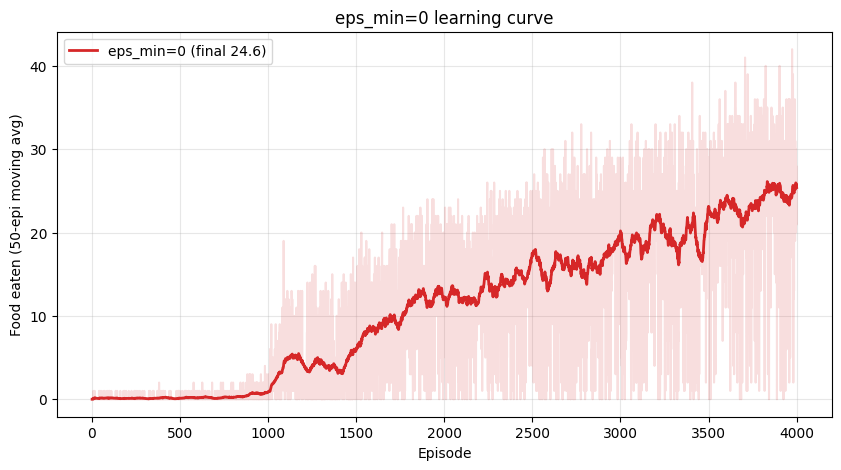

In [9]:
def plot_history(history):
    s = history["scores"]; x = np.arange(1, len(s)+1)
    def mavg(a, k=50): return [np.mean(a[max(0,i-k+1):i+1]) for i in range(len(a))]
    plt.figure(figsize=(10, 5))
    plt.plot(x, s, color="tab:red", alpha=0.15)
    plt.plot(x, mavg(s), color="tab:red", lw=2, label=f"eps_min=0 (final {np.mean(s[-300:]):.1f})")
    plt.xlabel("Episode"); plt.ylabel("Food eaten (50-epi moving avg)")
    plt.title("eps_min=0 learning curve")
    plt.legend(loc="upper left"); plt.grid(alpha=0.3); plt.show()

plot_history(history)


## eps_min=0.05 vs eps_min=0 

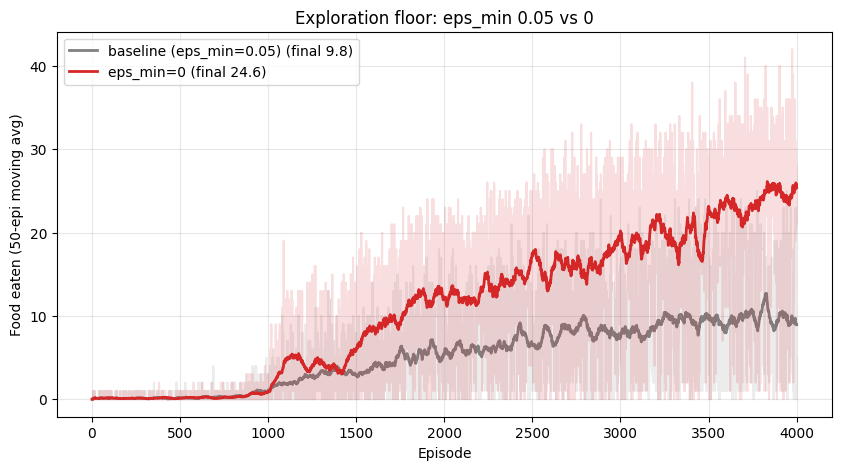

In [10]:
import numpy as np
def load_scores(name): return np.load(f"results/{name}/history.npz")["scores"]
def mavg(a, k=50): return np.array([np.mean(a[max(0,i-k+1):i+1]) for i in range(len(a))])

curves = [("baseline (eps_min=0.05)", "baseline_15k", "gray"),
          ("eps_min=0",              "cnn_eps0_only", "tab:red")]
plt.figure(figsize=(10, 5))
for label, name, color in curves:
    sc = load_scores(name); x = np.arange(1, len(sc)+1)
    plt.plot(x, sc, color=color, alpha=0.15)
    plt.plot(x, mavg(sc), color=color, lw=2, label=f"{label} (final {np.mean(sc[-300:]):.1f})")
plt.xlabel("Episode"); plt.ylabel("Food eaten (50-epi moving avg)")
plt.title("Exploration floor: eps_min 0.05 vs 0")
plt.legend(loc="upper left"); plt.grid(alpha=0.3); plt.show()


### eps_min=0 결과
![eps0 result](figs/eps0_typical.gif)
